# Are Purkinji cells using an encoding and not firing rate to encoding mouse arm position?

Currently we are using the Inverse Ising Problem to look at solve for a distribution to observe "proportional probability". Using the proportional probability we can analyze if a configuration is more probable then an other. This allows us to not need the partition function and enable us to experiment with information encoding of state configurations.

To ask hypothesis about the encoding, We can compare states to other states to see the differences in their probability. We can also construct a generator function of what the underlying dynamic might be and insert it into the distribution to see if it fits the current observation.

In this work I am testing the hypothesis that firing rate doesn't encode information regarding the arm reach rather the spike configuration encodes information about the arm reach.

I hypothesize that the firing rate is a measurement of a "gas pedal" to the activity of the neurons. Higher firing rate implies a faster alteration and adjustments being sent to the mouses limb. The exact adjustments is encoded in the state configuration.

## How to test this hypothesis

```state configuration --> H($\sigma$) --> Boltzman distrbution --> Proportional probability```

We are asking if the state configuration is encoding useful information

What is the balance between non-informative / informative?

If something is non-informative then it would be "Noisy" random activity would be more abundent
If something is informative then it would be biased.

Could we test a generator function that constructs random states or states biased and compare against the current graphs to determine what might be causing the underlying dynamic?

```
Observation to Test: firing rate can be observed to be covariant with probability inverse covariant to energy.
(Lets test this first)
```

```
test: Relationship between entropy of encoding and energy, Does lower energy / high probability corrolate with biased configuration?
- Mazen thinks that if we take do an NCr on number of spike, states that have a higher energy exist around 50% being active. Is this true?
```

Experiment to put together, 

The first part of the reach when no activity is happening, what could be the neural activity? Is is nose or is their an encoding?

During the max velocity at the beginning of the reach, how does neural encoding behave differently? 

How does neural encoding change reach by reach per stim and stim per stim.

```
Another question:
If the inverse ising problem is solved for individual reaches rather then the full stim what does that tell us?
```

In [2]:
!pip3 install matplotlib
!pip3 install pandas
!pip3 install h5py
!pip3 install scipy numba cython multiprocess boost==1.74

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
  Using cached numba-0.60.0-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.7 kB)
  Using cached cython-3.2.1-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (6.7 kB)
  Using cached multiprocess-0.70.18-py39-none-any.whl.metadata (7.5 kB)
ERROR: Could not find a version that satisfies the requ

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os

In [8]:
folder_of_data = "/data001/projects/ising/energy_decomposition"

# Utility

In [4]:
def find_file_recursive(root_folder, file_name, current_depth=0, max_depth=None, verbose=True):
    """
    Recursively search for a file in all subdirectories
    
    Args:
        root_folder (str): Path to start searching from
        file_name (str): Name of the file to look for
        current_depth (int): Current recursion depth (for display purposes)
        max_depth (int): Maximum depth to search (None for unlimited)
        verbose (bool): Whether to print detailed output
    
    Returns:
        list: List of paths where the file was found
    """
    found_paths = []
    indent = "  " * current_depth
    
    # Check if we've reached max depth
    if max_depth is not None and current_depth > max_depth:
        return found_paths
    
    # Normalize the path to handle different path separators
    root_folder = os.path.normpath(root_folder)
    
    # Check if the folder exists and is accessible
    if not os.path.exists(root_folder):
        if verbose:
            print(f"{indent}❌ Folder does not exist: {root_folder}")
        return found_paths
    
    if not os.path.isdir(root_folder):
        if verbose:
            print(f"{indent}❌ Not a directory: {root_folder}")
        return found_paths
    
    try:
        items = os.listdir(root_folder)
    except PermissionError:
        if verbose:
            print(f"{indent}❌ Permission denied: {root_folder}")
        return found_paths
    except Exception as e:
        if verbose:
            print(f"{indent}❌ Error accessing {root_folder}: {e}")
        return found_paths
    
    if verbose:
        print(f"{indent}📁 Searching in: {root_folder}")
    
    # Check if the file exists in current directory
    file_path = os.path.join(root_folder, file_name)
    if os.path.isfile(file_path):  # Use isfile instead of exists to ensure it's a file
        if verbose:
            print(f"{indent}  ✅ Found '{file_name}'")
        found_paths.append(file_path)
    else:
        if verbose:
            print(f"{indent}  ❌ '{file_name}' not found")
    
    # Recursively search in subdirectories
    subdirs = []
    for item in items:
        item_path = os.path.join(root_folder, item)
        if os.path.isdir(item_path):
            subdirs.append(item_path)
    
    if verbose and subdirs:
        print(f"{indent}  📂 Found {len(subdirs)} subdirectories")
    
    for subdir in subdirs:
        try:
            subfolder_results = find_file_recursive(subdir, file_name, current_depth + 1, max_depth, verbose)
            found_paths.extend(subfolder_results)
        except Exception as e:
            if verbose:
                print(f"{indent}  ❌ Error processing {subdir}: {e}")
    
    return found_paths

In [5]:
def extract_results_folder(file_path):
    """
    Extract the folder name that ends with '_results' from a file path
    
    Args:
        file_path (str): Full path to a file
        
    Returns:
        str: The folder name ending with '_results', or None if not found
    """
    # Split the path into components
    path_parts = file_path.split(os.sep)
    
    # Look for a folder that ends with '_results'
    for part in path_parts:
        if part.endswith('_results'):
            return part
    
    return None

In [6]:
def ensure_directory_exists(directory_path):
    """
    Check if a directory exists and create it (including all parent directories) if it doesn't.
    
    Args:
        directory_path (str): Path to the directory to check/create
    
    Returns:
        bool: True if directory exists or was created successfully, False if creation failed
    """
    try:
        os.makedirs(directory_path, exist_ok=True)
        return True
    except Exception as e:
        print(f"Error creating directory '{directory_path}': {e}")
        return False

In [51]:
import pandas as pd
import scipy.io as spio
import numpy as np
import scipy

def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    def _check_keys(d):
        '''
        checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        '''
        for key in d:
            if isinstance(d[key], scipy.io.matlab.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        '''
        A recursive function which constructs from matobjects nested dictionaries
        '''
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, scipy.io.matlab.mat_struct):
                d[strg] = _todict(elem)
            elif isinstance(elem, np.ndarray):
                d[strg] = _tolist(elem)
            else:
                d[strg] = elem
        return d

    def _tolist(ndarray):
        '''
        A recursive function which constructs lists from cellarrays
        (which are loaded as numpy ndarrays), recursing into the elements
        if they contain matobjects.
        '''
        elem_list = []
        for sub_elem in ndarray:
            if isinstance(sub_elem, scipy.io.matlab.mat_struct):
                elem_list.append(_todict(sub_elem))
            elif isinstance(sub_elem, np.ndarray):
                elem_list.append(_tolist(sub_elem))
            else:
                elem_list.append(sub_elem)
        return elem_list
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

In [58]:
# include acceleration and impulse
from scipy.interpolate import InterpolatedUnivariateSpline

def velocity_to_acceleration(timesteps, velocity):

  sp = InterpolatedUnivariateSpline(timesteps,velocity)
  return sp.derivative()(timesteps)

In [9]:
# review files of path saved in folder_of_data variables
# not all mice have full data, still working on incomplete mice
# This will help you select which csv in the path to use
all_reach_states = find_file_recursive(folder_of_data, "per_reach_state.csv")

📁 Searching in: /data001/projects/ising/energy_decomposition
  ❌ 'per_reach_state.csv' not found
  📂 Found 23 subdirectories
  📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results
    ❌ 'per_reach_state.csv' not found
    📂 Found 1 subdirectories
    📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1
      ❌ 'per_reach_state.csv' not found
      📂 Found 4 subdirectories
      📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1/begin_reach
        ❌ 'per_reach_state.csv' not found
      📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1/mid_reach
        ❌ 'per_reach_state.csv' not found
      📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1/post_reach
        ❌ 'per_reach_state.csv' not found
      📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1/full_reach
        ❌ 'per_reach_

# Experiments

In [10]:
# Test of the firing rate is covariance with probability or energy
print("Columns: ")
import numpy as np
print("- "+"\n- ".join(pd.read_csv(all_reach_states[0]).columns))
print(all_reach_states[5])
reach = pd.read_csv(all_reach_states[3])

reach[np.logical_and(reach['reach_idx'] == 0, reach['stim'] == 0)]

Columns: 
- reach_idx
- stim
- x
- y
- z
- firing_rate
- energy
- j
- h
/data001/projects/ising/energy_decomposition/210425_results/210425_rep1/mid_reach/per_reach_state.csv


,reach_idx,stim,x,y,z,firing_rate,energy,j,h
0,0,0,0.026840,0.118307,0.811070,0.133333,-0.044844,0.00000,0.044844
1,0,0,0.026830,0.118189,0.811066,0.142857,-0.049972,0.00000,0.049972
2,0,0,0.026794,0.118156,0.811135,0.125000,0.206248,0.00000,-0.206248
3,0,0,0.026739,0.118220,0.811268,0.133333,-0.000000,0.00000,0.000000
4,0,0,0.026693,0.118371,0.811452,0.120000,0.206248,0.00000,-0.206248
...,...,...,...,...,...,...,...,...,...
695,0,0,0.098536,0.062668,0.410207,0.120000,-0.158886,0.06407,0.094816
696,0,0,0.097551,0.063265,0.411807,0.111111,-0.000000,0.00000,0.000000
697,0,0,0.096537,0.063903,0.413030,0.125000,-0.000000,0.00000,0.000000
698,0,0,0.095601,0.064542,0.413826,0.114286,-0.000000,0.00000,0.000000


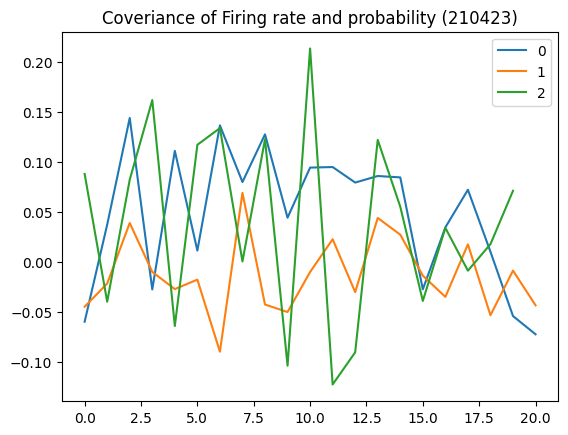

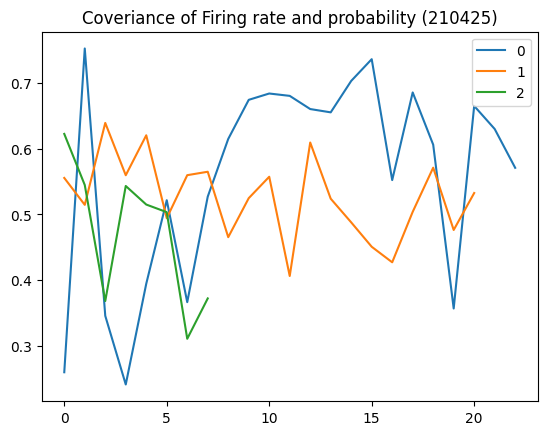

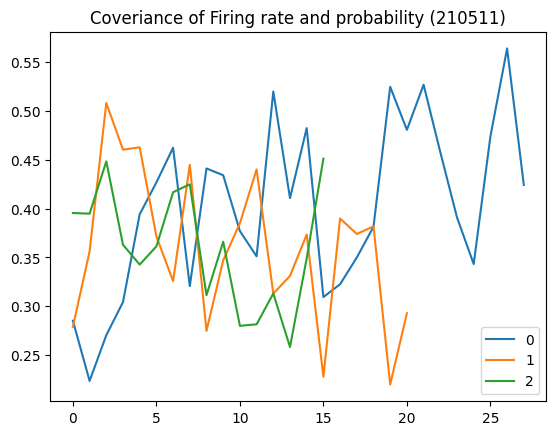

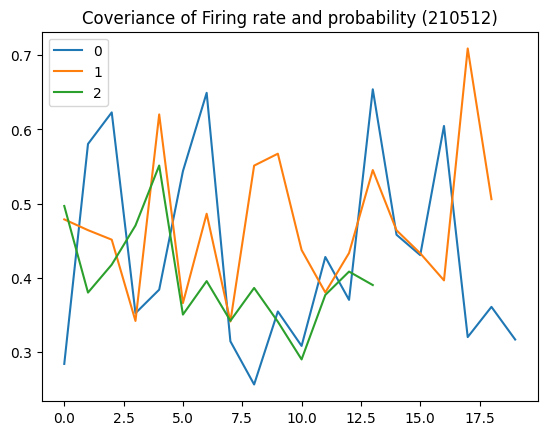

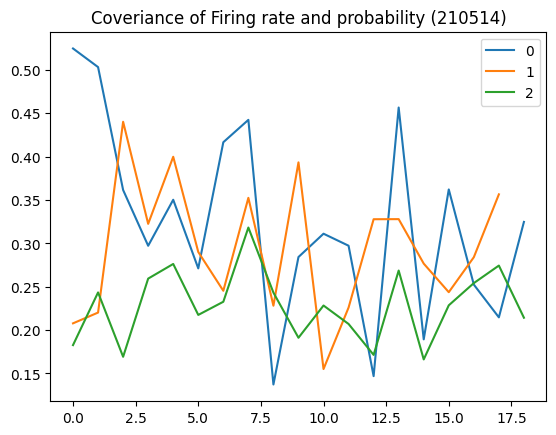

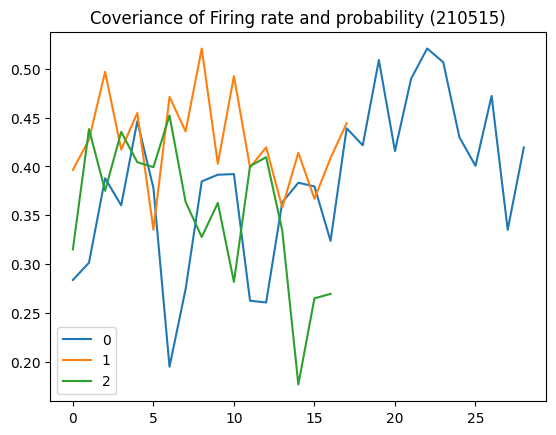

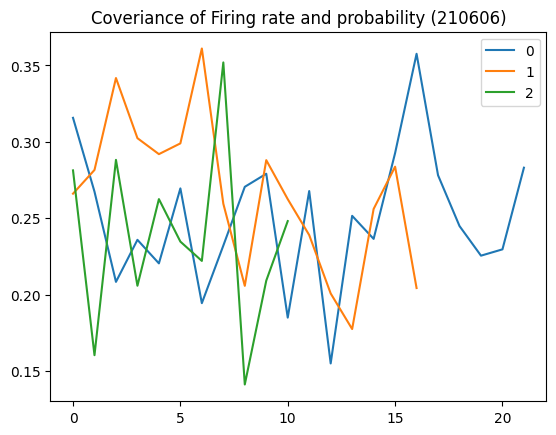

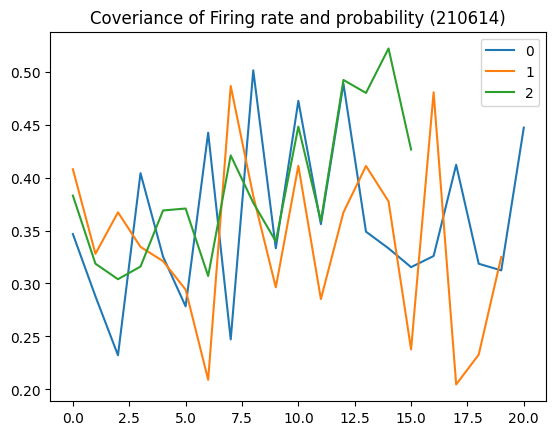

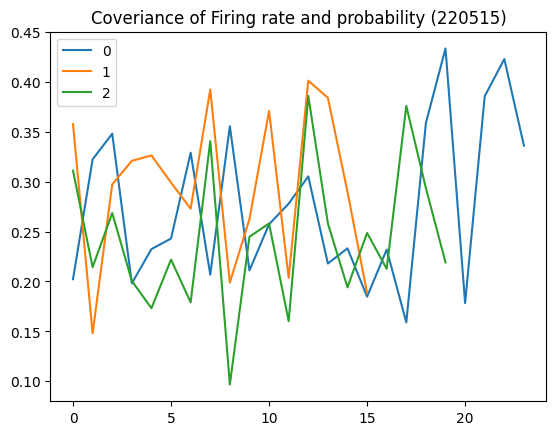

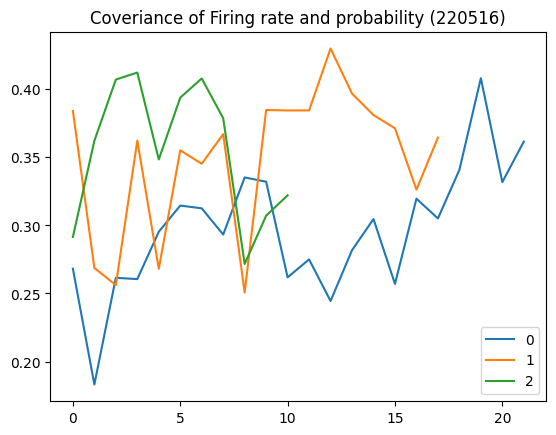

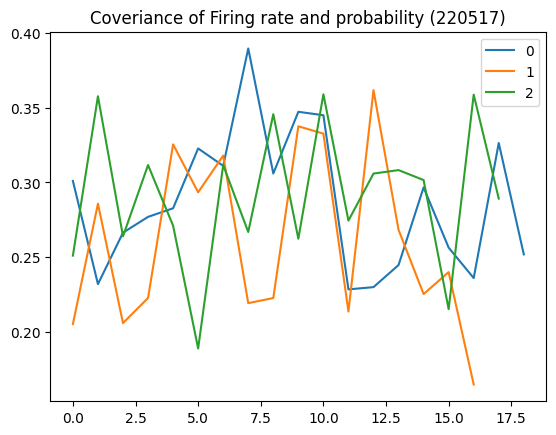

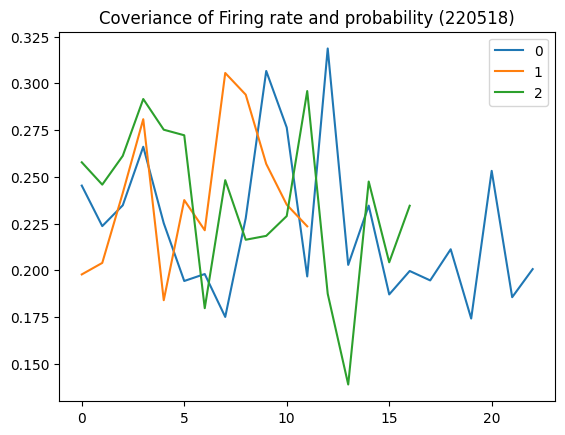

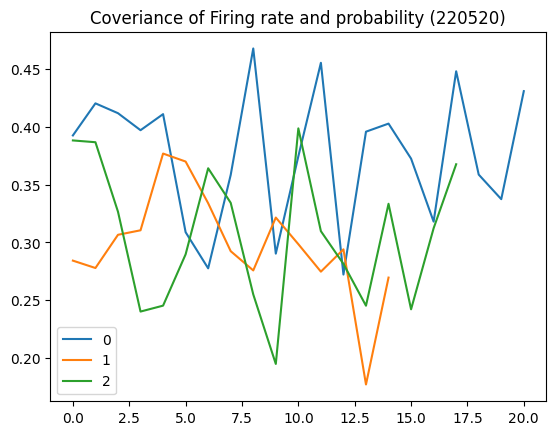

In [50]:
for session in all_reach_states:

    if not "full_reach" in session:
        continue
    
    # reachs
    reaches = pd.read_csv(session)

    unique_stim = reaches['stim'].unique()

    all_reaches_cov = []
    session_id = session.split('_results')[0][-6:]
    plt.title(f"Coveriance of Firing rate and probability ({session_id})")
    
    for stim in unique_stim:

        unique_reach_idx = reaches[reaches['stim'] == stim]['reach_idx'].unique()
        
        for reach_idx in unique_reach_idx:

            specific_reach = reaches[np.logical_and(reaches['reach_idx'] == reach_idx, reaches['stim'] == stim)]        

            try:
    
                fr = specific_reach['firing_rate']
                energy = np.exp(-specific_reach['energy'])

                stacked = np.stack((fr, energy), axis=0)
                
                cov_mat = np.corrcoef(stacked)[0,1]
                all_reaches_cov += [cov_mat]
            except:
                print(f"Issue: {stim},{reach_idx}")


        # print(all_reaches_cov)
        plt.plot(all_reaches_cov, label=f"{stim}")
        
        # print(all_reaches_cov)
        all_reaches_cov = []
    
    plt.legend()
    plt.show()

In [56]:
b = loadmat('/data001/projects/enserrog/AbigailData/energy_over_time/210421_fChR2_bin10_spike.mat')

In [59]:
neural_stim = []
continous_stim = []

truncate_idx = 400

for i in b['kinAggrogate'].keys():

    print(i)
    stim = b['kinAggrogate'][i]

    neural_session = []
    continous_sessions = []

    for k in stim.keys():
        print(f"\t Organizing {k}")
        dataMatrix = np.array(stim[k])

        if k[0] == "n":

            neural_session += [dataMatrix[:truncate_idx,1:]]

        if k[0:2] == "l_":

            x = velocity_to_acceleration(dataMatrix[:truncate_idx,0], dataMatrix[:truncate_idx,-3]).reshape(-1,1)
            y = velocity_to_acceleration(dataMatrix[:truncate_idx,0], dataMatrix[:truncate_idx,-2]).reshape(-1,1)
            z = velocity_to_acceleration(dataMatrix[:truncate_idx,0], dataMatrix[:truncate_idx,-1]).reshape(-1,1)

            print(dataMatrix.shape, x.shape)

            dataMatrix = np.hstack([dataMatrix[:truncate_idx], x, y, z])

            continous_sessions += [dataMatrix[:,1:]]


    neural_stim += [neural_session]
    continous_stim += [continous_sessions]

stim_0
	 Organizing l_1
(1002, 8) (400, 1)
	 Organizing n_1
	 Organizing label_1
	 Organizing l_2
(1000, 8) (400, 1)
	 Organizing n_2
	 Organizing label_2
	 Organizing l_3
(1004, 8) (400, 1)
	 Organizing n_3
	 Organizing label_3
	 Organizing l_4
(1006, 8) (400, 1)
	 Organizing n_4
	 Organizing label_4
	 Organizing l_5
(1008, 8) (400, 1)
	 Organizing n_5
	 Organizing label_5
	 Organizing l_6
(1016, 8) (400, 1)
	 Organizing n_6
	 Organizing label_6
	 Organizing l_7
(1003, 8) (400, 1)
	 Organizing n_7
	 Organizing label_7
	 Organizing l_8
(1009, 8) (400, 1)
	 Organizing n_8
	 Organizing label_8
	 Organizing l_9
(1007, 8) (400, 1)
	 Organizing n_9
	 Organizing label_9
	 Organizing l_10
(1001, 8) (400, 1)
	 Organizing n_10
	 Organizing label_10
	 Organizing l_11
(1007, 8) (400, 1)
	 Organizing n_11
	 Organizing label_11
	 Organizing l_12
(1001, 8) (400, 1)
	 Organizing n_12
	 Organizing label_12
	 Organizing l_13
(1006, 8) (400, 1)
	 Organizing n_13
	 Organizing label_13
	 Organizing l_14
(